In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/alfathterry/telco-customer-churn-11-1-3/telco.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


In [3]:
df = pd.read_csv('/kaggle/input/datasets/alfathterry/telco-customer-churn-11-1-3/telco.csv')
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [4]:
df.shape

(7043, 50)

In [5]:
df.tail()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
7038,2569-WGERO,Female,30,No,No,No,No,0,United States,California,...,0,1639.44,3039.53,5,Stayed,No,45,5306,NaN,NaN
7039,6840-RESVB,Male,38,No,No,Yes,Yes,2,United States,California,...,0,865.20,2807.47,3,Stayed,No,59,2140,NaN,NaN
7040,2234-XADUH,Female,30,No,No,Yes,Yes,2,United States,California,...,0,2135.52,9453.04,4,Stayed,No,71,5560,NaN,NaN
7041,4801-JZAZL,Female,32,No,No,Yes,Yes,2,United States,California,...,0,0.00,319.21,4,Stayed,No,59,2793,NaN,NaN
7042,3186-AJIEK,Male,44,No,No,No,No,0,United States,California,...,0,2043.36,8887.86,4,Stayed,No,38,5097,NaN,NaN


In [6]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [8]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [9]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Country"]. value_counts()

Country
United States    7043
Name: count, dtype: int64

In [12]:
df["State"]. value_counts()

State
California    7043
Name: count, dtype: int64

In [13]:
df["City"].value_counts()

City
Los Angeles         293
San Diego           285
San Jose            112
Sacramento          108
San Francisco       104
                   ... 
Eldridge              2
South Lake Tahoe      2
Johannesburg          2
Jacumba               2
Holtville             2
Name: count, Length: 1106, dtype: int64

In [14]:
df_clean = df.copy()

df_clean = df_clean.drop(
    columns=["Customer ID","Churn Category","Churn Reason","Customer Status","Country","State"]
)

In [15]:
df_clean["Offer"] = df_clean["Offer"].fillna("No Offer")

df_clean["Internet Type"] = df_clean["Internet Type"].fillna("No Internet")

df_clean.head()

,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,City,Zip Code,Latitude,...,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Label,Churn Score,CLTV
0,Male,78,No,Yes,No,No,0,Los Angeles,90022,34.023810,...,39.65,39.65,0.00,20,0.00,59.65,3,Yes,91,5433
1,Female,74,No,Yes,Yes,Yes,1,Los Angeles,90063,34.044271,...,80.65,633.30,0.00,0,390.80,1024.10,3,Yes,69,5302
2,Male,71,No,Yes,No,Yes,3,Los Angeles,90065,34.108833,...,95.45,1752.55,45.61,0,203.94,1910.88,2,Yes,81,3179
3,Female,78,No,Yes,Yes,Yes,1,Inglewood,90303,33.936291,...,98.50,2514.50,13.43,0,494.00,2995.07,2,Yes,88,5337
4,Female,80,No,Yes,Yes,Yes,1,Whittier,90602,33.972119,...,76.50,2868.15,0.00,0,234.21,3102.36,2,Yes,67,2793


In [16]:
df_clean["Churn Label"]. value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [17]:
df_clean["Churn Label"]. value_counts(normalize=True)* 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [18]:
pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn Label"]
)

Churn Label,No,Yes
Contract,,
Month-to-Month,1955,1655
One Year,1384,166
Two Year,1835,48


In [19]:
pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Contract,,
Month-to-Month,54.155125,45.844875
One Year,89.290323,10.709677
Two Year,97.450876,2.549124


In [20]:
df_clean.groupby("Churn Label")["Monthly Charge"].mean()

Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charge, dtype: float64

In [21]:
pd.crosstab(
    df_clean["Payment Method"],
    df_clean["Churn Label"]
)

Churn Label,No,Yes
Payment Method,,
Bank Withdrawal,2580,1329
Credit Card,2351,398
Mailed Check,243,142


In [22]:
pd.crosstab(
    df_clean["Internet Type"],
    df_clean["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Internet Type,,
Cable,74.337349,25.662651
DSL,81.416465,18.583535
Fiber Optic,59.275124,40.724876
No Internet,92.595020,7.404980


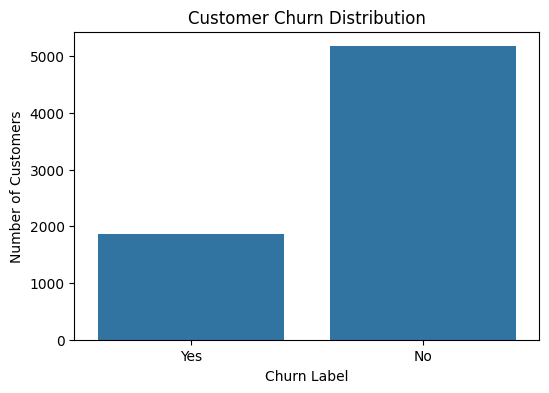

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(data=df_clean, x="Churn Label")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Label")
plt.ylabel("Number of Customers")
plt.show()

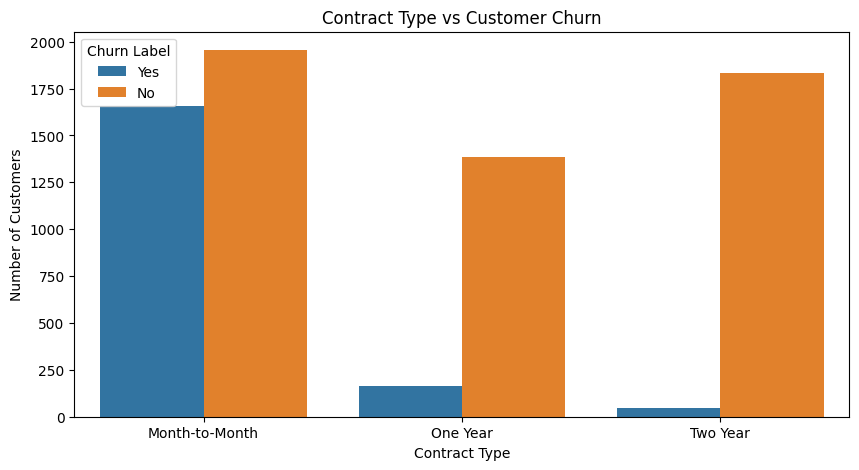

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    x="Contract",
    hue="Churn Label"
)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

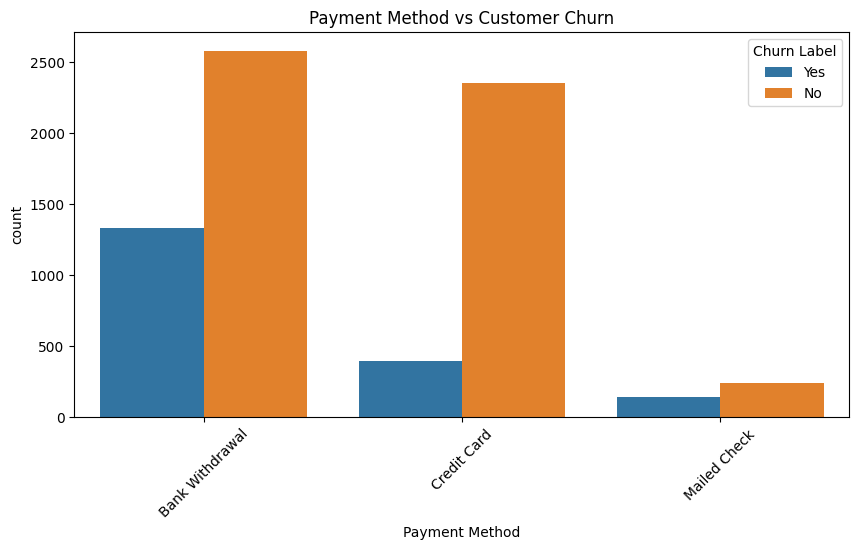

In [25]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    x="Payment Method",
    hue="Churn Label"
)

plt.title("Payment Method vs Customer Churn")
plt.xticks(rotation=45)
plt.show()

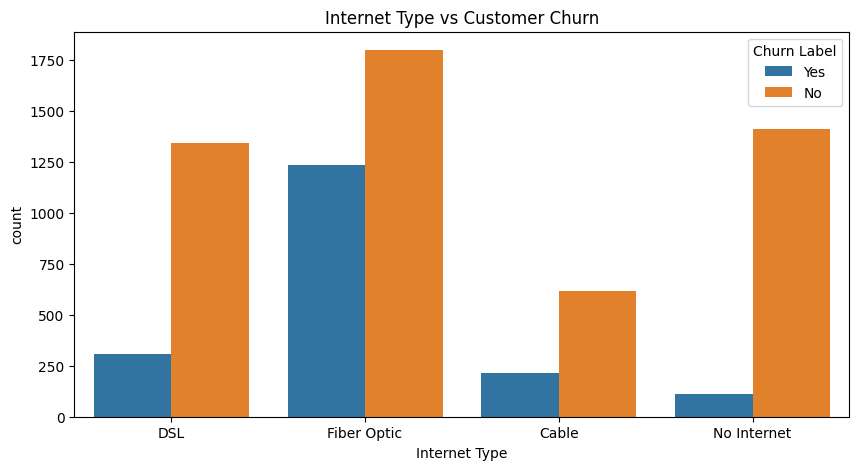

In [26]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    x="Internet Type",
    hue="Churn Label"
)

plt.title("Internet Type vs Customer Churn")
plt.show()

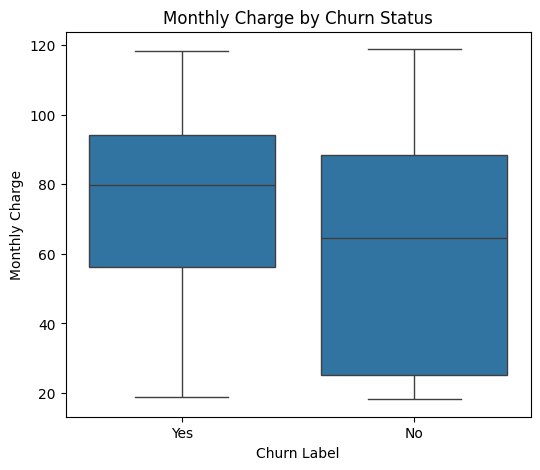

In [27]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_clean,
    x="Churn Label",
    y="Monthly Charge"
)

plt.title("Monthly Charge by Churn Status")
plt.show()

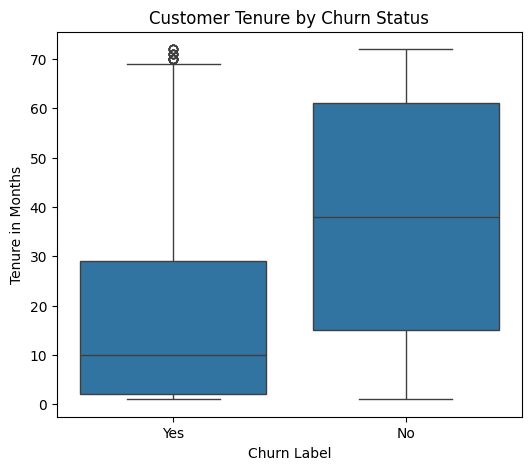

In [28]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_clean,
    x="Churn Label",
    y="Tenure in Months"
)

plt.title("Customer Tenure by Churn Status")
plt.show()

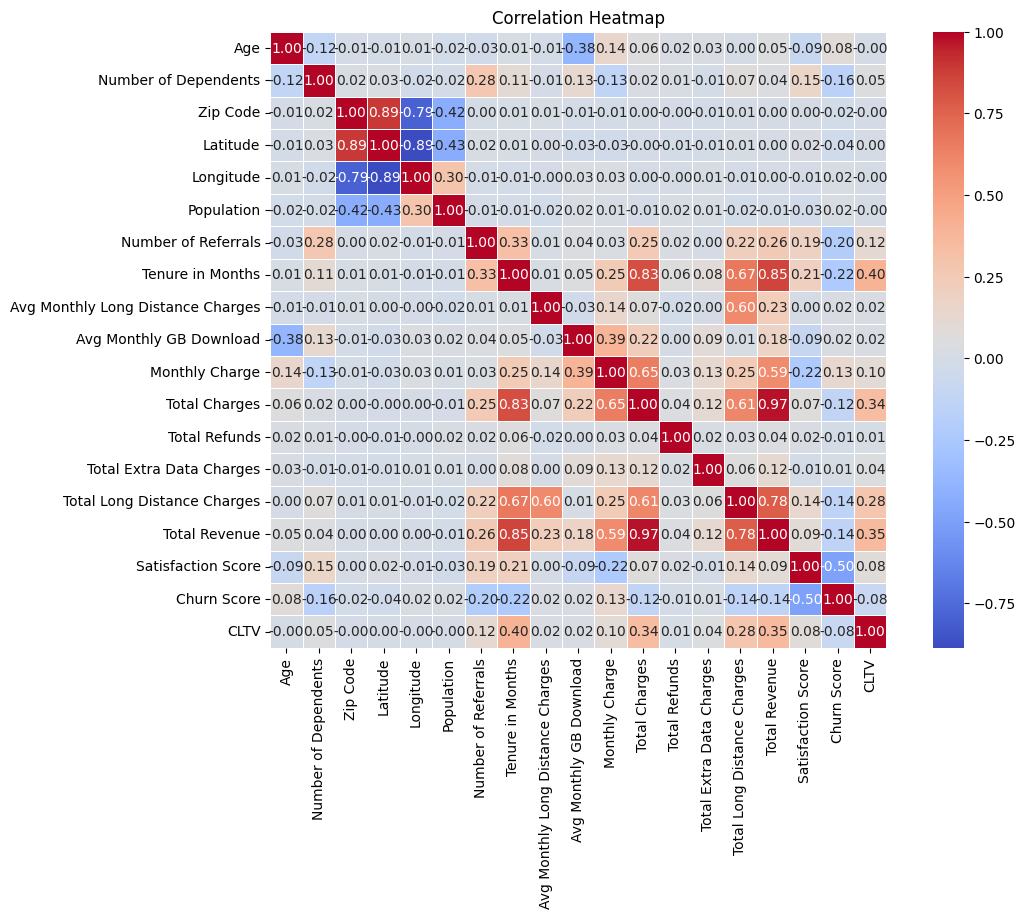

In [29]:
correlation = df_clean.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap")
plt.show()

In [30]:
df_clean["Churn"] = df_clean["Churn Label"].map({"No": 0, "Yes": 1})

In [31]:
df_model = df_clean.copy()

df_model = df_model.drop(
    columns=["City","Zip Code","Latitude","Longitude"]
)

In [32]:
X = df_model.drop(["Churn Label","Churn","Churn Score"], axis=1)
y = df_model["Churn Label"]

In [33]:
X.head()

,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Population,Quarter,Referred a Friend,...,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,CLTV
0,Male,78,No,Yes,No,No,0,68701,Q3,No,...,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,5433
1,Female,74,No,Yes,Yes,Yes,1,55668,Q3,Yes,...,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,5302
2,Male,71,No,Yes,No,Yes,3,47534,Q3,No,...,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,3179
3,Female,78,No,Yes,Yes,Yes,1,27778,Q3,Yes,...,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,5337
4,Female,80,No,Yes,Yes,Yes,1,26265,Q3,Yes,...,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,2793


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 38)
(1409, 38)
(5634,)
(1409,)


In [36]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

In [39]:
pipeline_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Number of Dependents', 'Population', 'Number of Referrals',
       'Tenure in Months', 'Avg Monthly Long Distance Charges',
       'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges',
       'Total Refunds', 'Total Extra Data Charges',
       'Total Long Distance Charges', 'Total Revenue', 'Satisfacti...
       'Quarter', 'Referred a Friend', 'Offer', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Internet Type',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method'],
      dtype='object'))])),
                ('classifier', LogisticRegression(random_state=42))])

In [40]:
y_pred_lr = pipeline_lr.predict(X_test)

In [41]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear", "lbfgs"]
}

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best Cross-validation Score:", grid_lr.best_score_)

Best Parameters: {'classifier__C': 1, 'classifier__solver': 'liblinear'}
Best Cross-validation Score: 0.9611280360472245


In [42]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9616749467707594
              precision    recall  f1-score   support

          No       0.96      0.98      0.97      1035
         Yes       0.95      0.90      0.93       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



In [43]:
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[1018   17]
 [  37  337]]


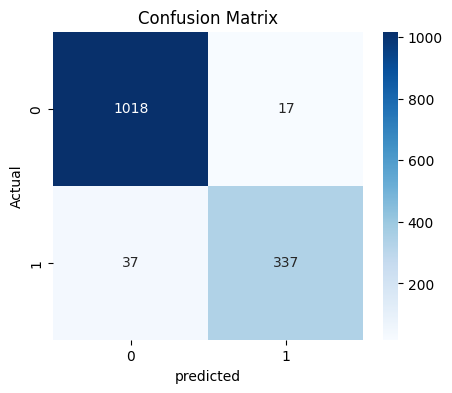

In [44]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [45]:
pipeline_knn = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier())
])

In [46]:
pipeline_knn.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Number of Dependents', 'Population', 'Number of Referrals',
       'Tenure in Months', 'Avg Monthly Long Distance Charges',
       'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges',
       'Total Refunds', 'Total Extra Data Charges',
       'Total Long Distance Charges', 'Total Revenue', 'Satisfacti...
                                                  Index(['Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents',
       'Quarter', 'Referred a Friend', 'Offer', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Internet Type',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method'],
      dtype='object'))])),
                ('classifier', KNeighborsClassifier())])

In [47]:
y_pred_knn = pipeline_knn.predict(X_test)

In [48]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11]
}

grid_knn = GridSearchCV(
    pipeline_knn,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid_knn.fit(X_train, y_train)

print("Best Parameters:", grid_knn.best_params_)
print("Best Cross-validation Score:", grid_knn.best_score_)

Best Parameters: {'classifier__n_neighbors': 9}
Best Cross-validation Score: 0.9194165178620679


In [49]:
print("Accuracy:", accuracy_score(y_test,y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.9240596167494677
              precision    recall  f1-score   support

          No       0.94      0.96      0.95      1035
         Yes       0.88      0.82      0.85       374

    accuracy                           0.92      1409
   macro avg       0.91      0.89      0.90      1409
weighted avg       0.92      0.92      0.92      1409



In [50]:
cm = confusion_matrix(y_test, y_pred_knn)
print(cm)

[[995  40]
 [ 67 307]]


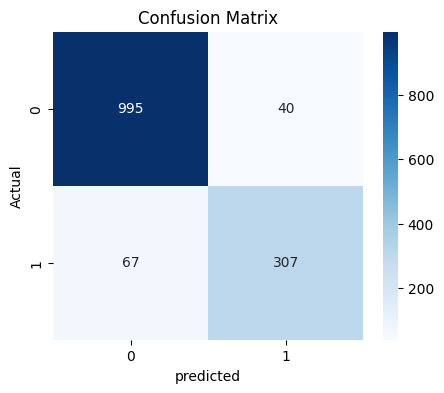

In [51]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [52]:
pipeline_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

In [53]:
pipeline_dt.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Number of Dependents', 'Population', 'Number of Referrals',
       'Tenure in Months', 'Avg Monthly Long Distance Charges',
       'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges',
       'Total Refunds', 'Total Extra Data Charges',
       'Total Long Distance Charges', 'Total Revenue', 'Satisfacti...
       'Quarter', 'Referred a Friend', 'Offer', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Internet Type',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method'],
      dtype='object'))])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [54]:
y_pred_dt = pipeline_dt.predict(X_test)

In [55]:
param_grid = {
    "classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

grid_dt = GridSearchCV(
    pipeline_dt,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best Cross-validation Score:", grid_dt.best_score_)

Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5}
Best Cross-validation Score: 0.9503011027563393


In [56]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.950319375443577
              precision    recall  f1-score   support

          No       0.96      0.97      0.97      1035
         Yes       0.91      0.90      0.91       374

    accuracy                           0.95      1409
   macro avg       0.94      0.93      0.94      1409
weighted avg       0.95      0.95      0.95      1409



In [57]:
cm = confusion_matrix(y_test, y_pred_dt)
print(cm)

[[1002   33]
 [  37  337]]


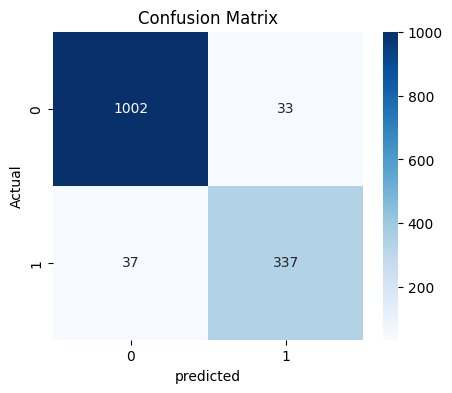

In [58]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [59]:
results = pd.DataFrame({
    "Model":[
        "Logistic regression",
        "KNN",
        "Decision Tree"
    ],
    "Accuracy":[
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ]
})

results

,Model,Accuracy
0,Logistic regression,0.961675
1,KNN,0.924060
2,Decision Tree,0.950319


In [60]:
feature_names = pipeline_lr.named_steps["preprocessor"].get_feature_names_out()

coefficients = pipeline_lr.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Absolute_Coefficient"] = abs(coef_df["Coefficient"])

coef_df = coef_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

coef_df.head(20)

,Feature,Coefficient,Absolute_Coefficient
13,num__Satisfaction Score,-6.891451,6.891451
3,num__Number of Referrals,-1.898574,1.898574
45,cat__Online Security_Yes,-1.542104,1.542104
24,cat__Dependents_Yes,-1.255863,1.255863
29,cat__Offer_Offer A,1.208920,1.208920
44,cat__Online Security_No,1.176350,1.176350
62,cat__Contract_Two Year,-1.051748,1.051748
23,cat__Dependents_No,0.890109,0.890109
7,num__Monthly Charge,0.843867,0.843867
4,num__Tenure in Months,-0.836096,0.836096


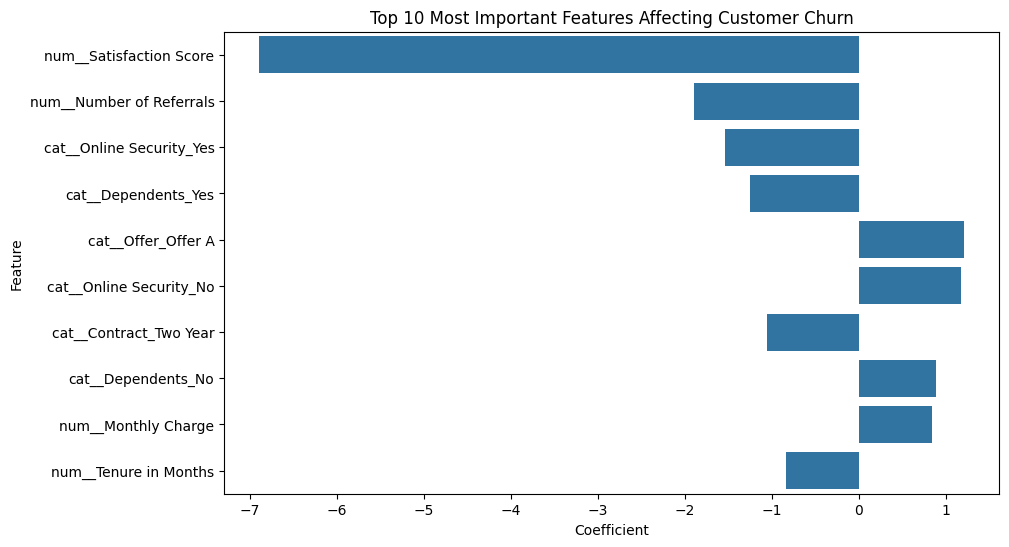

In [61]:
top10 = coef_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Most Important Features Affecting Customer Churn")
plt.show()